In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
from os.path import join 
import os 
import sys
sys.path.append("/n/home12/binxuwang/Github/DiffusionLearningCurve")
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import torch 
from torch import nn 

In [26]:
from core.img_patch_stats_analysis_lib import compute_crossing_points, plot_variance_trajectories
from core.trajectory_convergence_lib import analyze_and_plot_variance
from core.img_patch_stats_analysis_lib import process_img_mean_cov_statistics, process_patch_mean_cov_statistics, \
            sweep_and_create_sample_store, sweep_and_create_sample_store_custom_pattern

In [ ]:
exproot = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionReprCondModel/"
expname = "pilot_pixart_256px_2"
expdir = join(exproot, expname)
sampledir = join(expdir, "samples")

In [9]:
# Load all samples from directory
sample_store = sweep_and_create_sample_store_custom_pattern(sampledir)

regex_pattern: latents_epoch_(\d+)\.pt


  0%|          | 0/201 [00:00<?, ?it/s]

/n/home12/binxuwang/Github/DiffusionLearningCurve/core/img_patch_stats_analysis_lib.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample_store[epoch] = torch.load(sam

In [14]:
IN1k_val_dir = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/Datasets/imagenet-valid/"
latent_dir = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/Datasets/dcae_latents"
resolution = 256
model_ver_short = "dc-ae-f32c32-mix-1.0"
latent_tsr = torch.load(join(latent_dir, f"ffhq256_{resolution}px_{model_ver_short}_latent_tsr.pt"), weights_only=False)
# latent_tsr = torch.load(join(IN1k_val_dir, f"IN1k_valid_{model_ver_short}_latent_tsr.pt"), weights_only=False)

In [38]:
result = process_img_mean_cov_statistics(
            latent_tsr.contiguous(), sample_store, expdir, device="cuda", imgshape=(32, 8, 8), save_pkl=True)
img_mean, img_cov, img_eigval, img_eigvec, \
        mean_x_sample_traj, cov_x_sample_traj, diag_cov_x_sample_true_eigenbasis_traj = result

img_cov.shape: torch.Size([2048, 2048]) computed on 70000 images


  0%|          | 0/201 [00:00<?, ?it/s]

Saved to /n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionReprCondModel/pilot_pixart_256px_2/sample_img_cov_true_eigenbasis_diag_traj.pkl


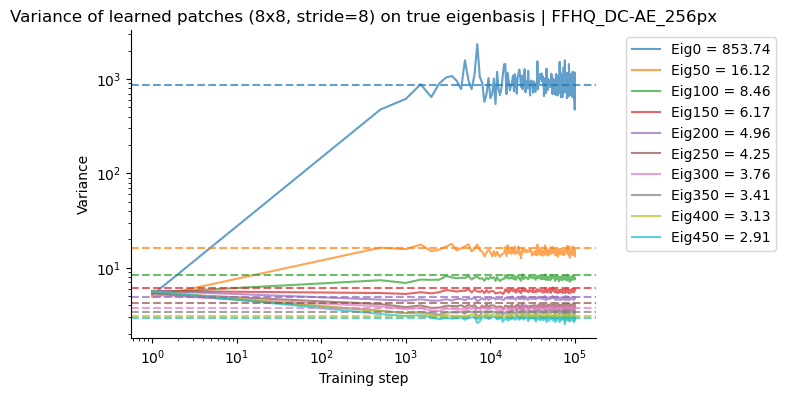

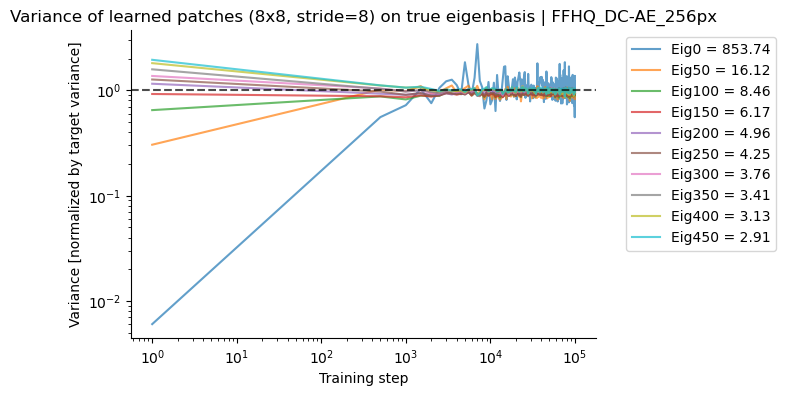

No crossing found for mode 0
No crossing found for mode 1
No crossing found for mode 2
No crossing found for mode 3
No crossing found for mode 5
No crossing found for mode 6
No crossing found for mode 7
No crossing found for mode 8
No crossing found for mode 10
No crossing found for mode 11
No crossing found for mode 12
No crossing found for mode 20
No crossing found for mode 21
No crossing found for mode 28
No crossing found for mode 50
No crossing found for mode 152
No crossing found for mode 157
No crossing found for mode 158
No crossing found for mode 161
No crossing found for mode 165
No crossing found for mode 166
No crossing found for mode 168
No crossing found for mode 169
No crossing found for mode 170
No crossing found for mode 171
No crossing found for mode 172
No crossing found for mode 173
No crossing found for mode 174
No crossing found for mode 175
No crossing found for mode 177
No crossing found for mode 178
No crossing found for mode 179
No crossing found for mode 180


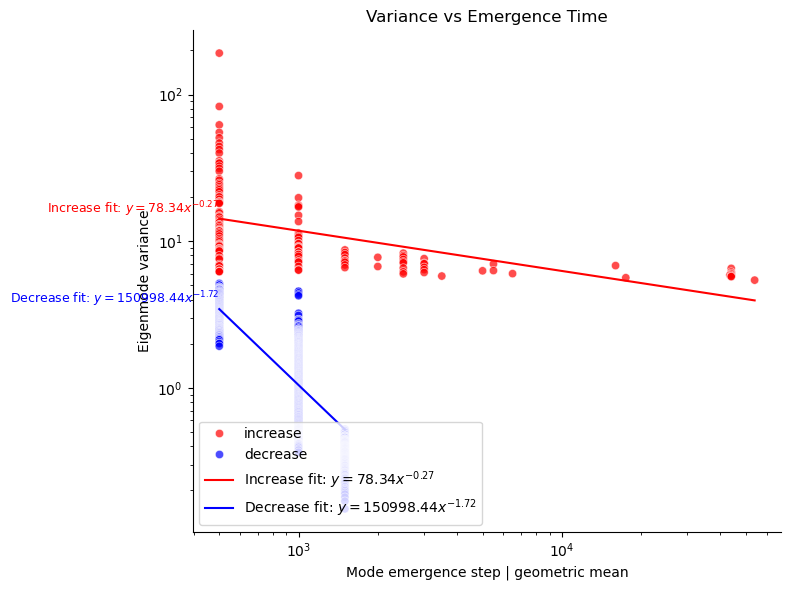

In [63]:
step_slice = sorted(list(sample_store.keys()))
# 1. Plot variance trajectories
plot_variance_trajectories(
    step_slice, 
    diag_cov_x_sample_true_eigenbasis_traj.cpu(), 
    img_eigval.cpu(), 
    slice2plot=slice(0, 500, 50),  
    patch_size=8, 
    patch_stride=8, 
    savedir=expdir, 
    dataset_name="FFHQ_DC-AE_256px"
)

# 2. Compute crossing points
# lr = 1e-4
# lr_step_slice = np.array(step_slice) * lr
df = compute_crossing_points(
    img_eigval.cpu(), 
    diag_cov_x_sample_true_eigenbasis_traj.cpu(), 
    step_slice, 
    smooth_sigma=1, 
    threshold_type="geometric_mean"
)
df.to_csv(f"{expdir}/eigenmode_emergence_vs_variance.csv", index=False)

# 3. Plot and analyze emergence scaling
figh = analyze_and_plot_variance(
    df, 
    x_col='emergence_step', 
    y_col='Variance', 
    hue_col='Direction',
    palette={"increase": "red", "decrease": "blue"},
    log_x=True, 
    log_y=True,
    title='Variance vs Emergence Time',
    xlabel='Mode emergence step | geometric mean',
    ylabel='Eigenmode variance'
)

Not enough data points to fit for direction: nan


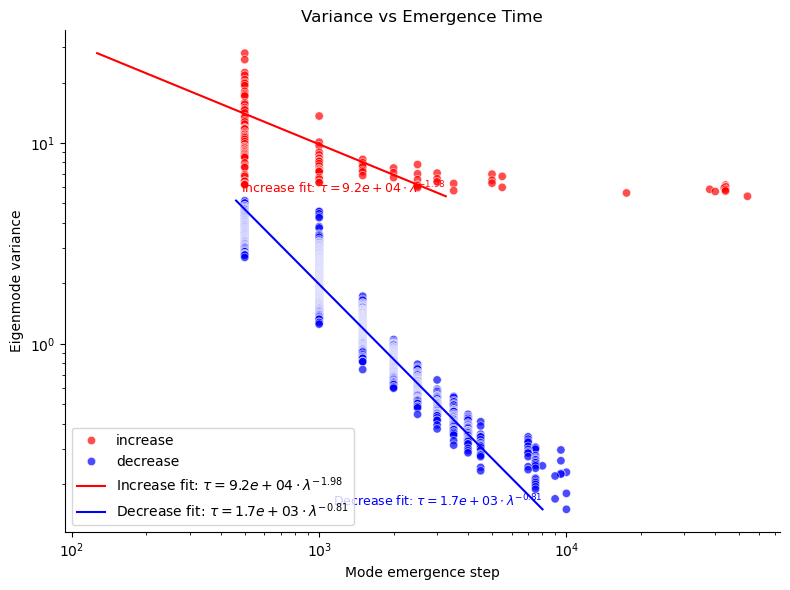

In [ ]:

df = compute_crossing_points(
    img_eigval, 
    diag_cov_x_sample_true_eigenbasis_traj.cpu(), 
    step_slice, 
    smooth_sigma=1, 
    threshold_type="geometric_mean"
)
# 3. Plot and analyze emergence scaling
figh = analyze_and_plot_variance(
    df, 
    x_col='emergence_step', 
    y_col='Variance', 
    hue_col='Direction',
    palette={"increase": "red", "decrease": "blue"},
    log_x=True, 
    log_y=True,
    reverse_equation=True,
    fit_label_format='{direction} fit: $\\tau = {a:.1e} \\cdot \\lambda^{{{b:.2f}}}$',
    title='Variance vs Emergence Time',
    xlabel='Mode emergence step',
    ylabel='Eigenmode variance'
)

In [51]:
[step_slice[i] for i in tick_indices]

[1, 14000, 28500, 42500, 57000, 71000, 85500, 100000]

In [53]:
tick_indices

array([  0,  28,  57,  85, 114, 142, 171, 200])

In [54]:
diag_cov_x_sample_true_eigenbasis_traj.log().cpu().numpy().T.shape

(2048, 201)

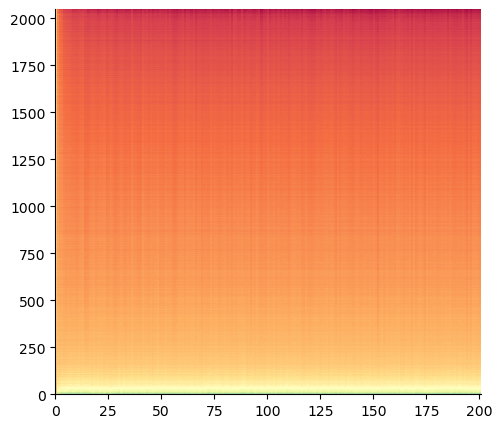

In [57]:
plt.figure(figsize=(5.5, 5))
plt.pcolor(diag_cov_x_sample_true_eigenbasis_traj.log().cpu().numpy().T, cmap="Spectral", rasterized=True)

In [58]:
df["emergence_step"].to_numpy()

array([   nan,    nan,    nan, ..., 10000.,  9000., 10000.])

No crossing found for mode 0
No crossing found for mode 1
No crossing found for mode 2
No crossing found for mode 3
No crossing found for mode 5
No crossing found for mode 6
No crossing found for mode 7
No crossing found for mode 8
No crossing found for mode 10
No crossing found for mode 11
No crossing found for mode 12
No crossing found for mode 20
No crossing found for mode 21
No crossing found for mode 28
No crossing found for mode 50
No crossing found for mode 152
No crossing found for mode 157
No crossing found for mode 158
No crossing found for mode 161
No crossing found for mode 165
No crossing found for mode 166
No crossing found for mode 168
No crossing found for mode 169
No crossing found for mode 170
No crossing found for mode 171
No crossing found for mode 172
No crossing found for mode 173
No crossing found for mode 174
No crossing found for mode 175
No crossing found for mode 177
No crossing found for mode 178
No crossing found for mode 179
No crossing found for mode 180


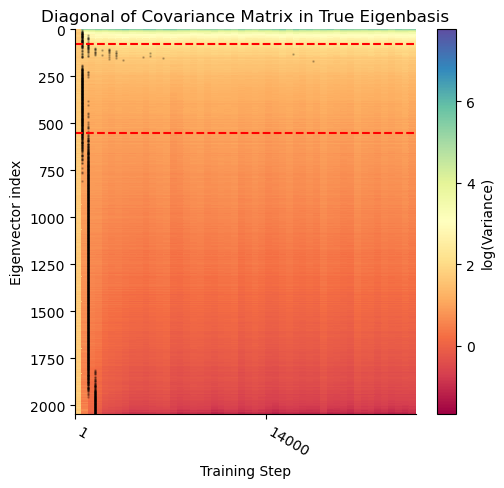

In [61]:
emer_time_df = compute_crossing_points(img_eigval.cpu(), diag_cov_x_sample_true_eigenbasis_traj.cpu(), 
                                       range(len(step_slice)), smooth_sigma=1, threshold_type="geometric_mean")
var_ratio = diag_cov_x_sample_true_eigenbasis_traj[0,:] / img_eigval.cpu()
eig_idx_tooclose = (var_ratio > 0.5) & (var_ratio < 2)
eig_idx_tooclose_vec = eig_idx_tooclose.nonzero()[:,0]

plt.figure(figsize=(5.5, 5))
plt.pcolor(diag_cov_x_sample_true_eigenbasis_traj.log().cpu().numpy().T, cmap="Spectral", rasterized=True)
plt.colorbar(label="log(Variance)")
plt.scatter(emer_time_df["emergence_step"].to_numpy(), emer_time_df.index.to_numpy(), marker=".", c="k", s=3, alpha=0.2, rasterized=True)
plt.axhline(eig_idx_tooclose_vec[0], color="r", linestyle="--")
plt.axhline(eig_idx_tooclose_vec[-1], color="r", linestyle="--")
plt.title("Diagonal of Covariance Matrix in True Eigenbasis")
plt.xlabel("Training Step")
plt.ylabel("Eigenvector index")
plt.gca().invert_yaxis()  # Flip the y-axis
# annotate x-axis with step_slice
# Only show a subset of ticks to avoid overcrowding
tick_indices = np.linspace(0, len(step_slice)-1, 8, dtype=int)
plt.xticks(tick_indices, [step_slice[i] for i in tick_indices], rotation=-30, ha="left")
# saveallforms(figdir, f"eigenframe_variance_heatmap_{expname}_rasterized", dpi=300)
plt.xlim(0,50)
plt.show()

### Small patch size

patch_cov.shape: torch.Size([32]) computed on 70000 images


  0%|          | 0/201 [00:00<?, ?it/s]

Saved to /n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionReprCondModel/pilot_pixart_256px_2/sample_patch_1x1_stride_1_cov_true_eigenbasis_diag_traj.pkl


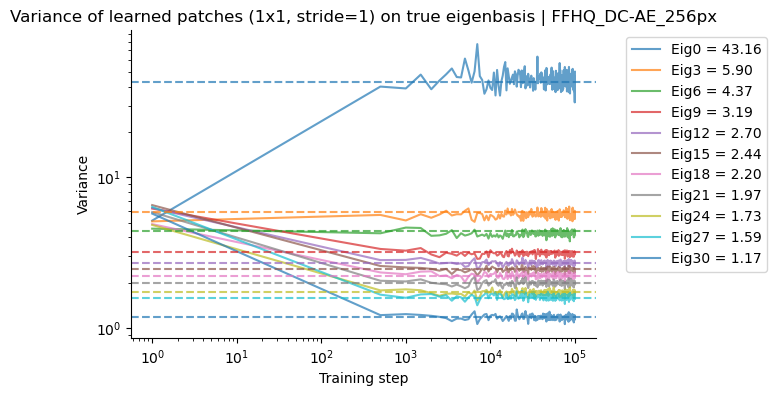

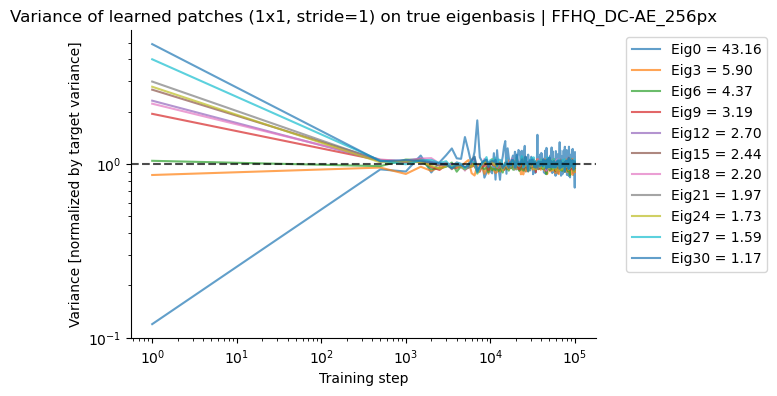

No crossing found for mode 0
Not enough data points to fit for direction: nan


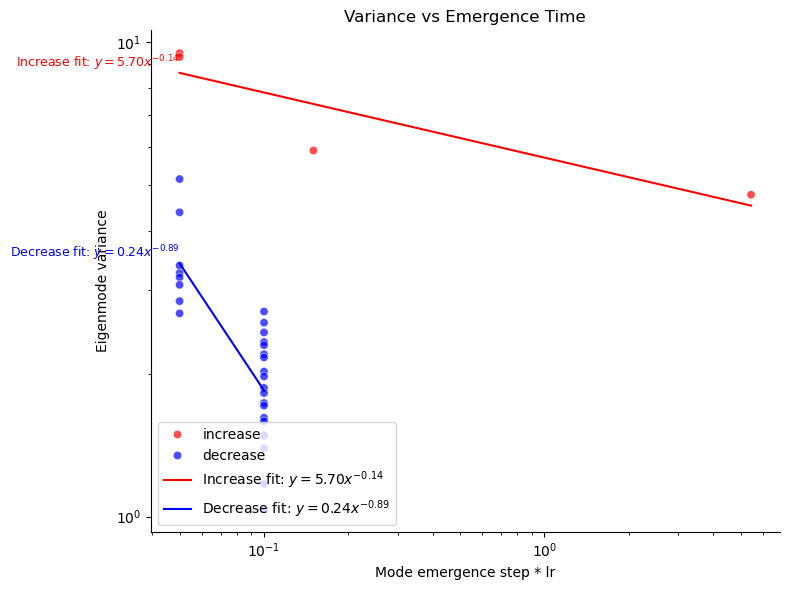

In [36]:
patch_size = 1
patch_stride = 1
result = process_patch_mean_cov_statistics(
            latent_tsr.contiguous(), sample_store, expdir, device="cuda", patch_size=patch_size, patch_stride=patch_stride, imgshape=(32, 8, 8), save_pkl=True)
img_mean, img_cov, img_eigval, img_eigvec, \
        mean_x_sample_traj, cov_x_sample_traj, diag_cov_x_sample_true_eigenbasis_traj = result
step_slice = sorted(list(sample_store.keys()))
# 1. Plot variance trajectories
plot_variance_trajectories(
    step_slice, 
    diag_cov_x_sample_true_eigenbasis_traj.cpu(), 
    img_eigval.cpu(), 
    slice2plot=slice(0, 32, 3),  
    patch_size=1, 
    patch_stride=1, 
    savedir=expdir, 
    dataset_name="FFHQ_DC-AE_256px"
)

# 2. Compute crossing points
lr = 1e-4
lr_step_slice = np.array(step_slice) * lr
df = compute_crossing_points(
    img_eigval, 
    diag_cov_x_sample_true_eigenbasis_traj.cpu(), 
    lr_step_slice, 
    smooth_sigma=1, 
    threshold_type="harmonic_mean"
)
df.to_csv(f"{expdir}/eigenmode_emergence_vs_variance_patch{patch_size}x{patch_size}_stride{patch_stride}.csv", index=False)

# 3. Plot and analyze emergence scaling
figh = analyze_and_plot_variance(
    df, 
    x_col='emergence_step', 
    y_col='Variance', 
    hue_col='Direction',
    palette={"increase": "red", "decrease": "blue"},
    log_x=True, 
    log_y=True,
    title='Variance vs Emergence Time',
    xlabel='Mode emergence step * lr',
    ylabel='Eigenmode variance'
)

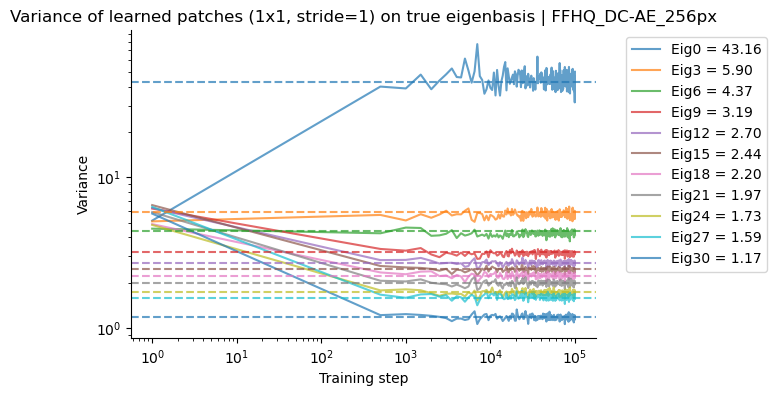

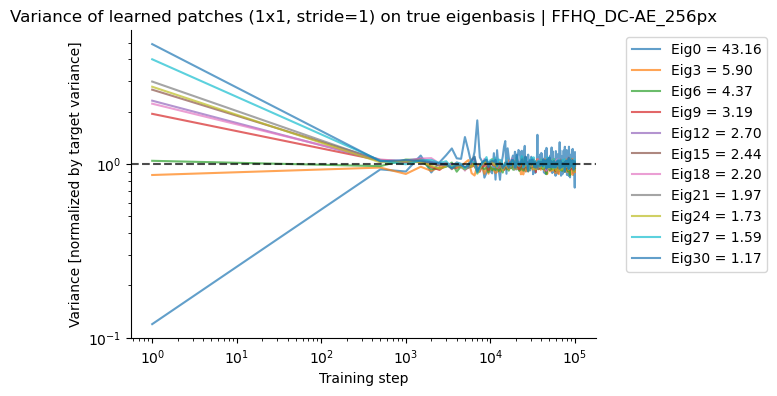

No crossing found for mode 0
Not enough data points to fit for direction: nan


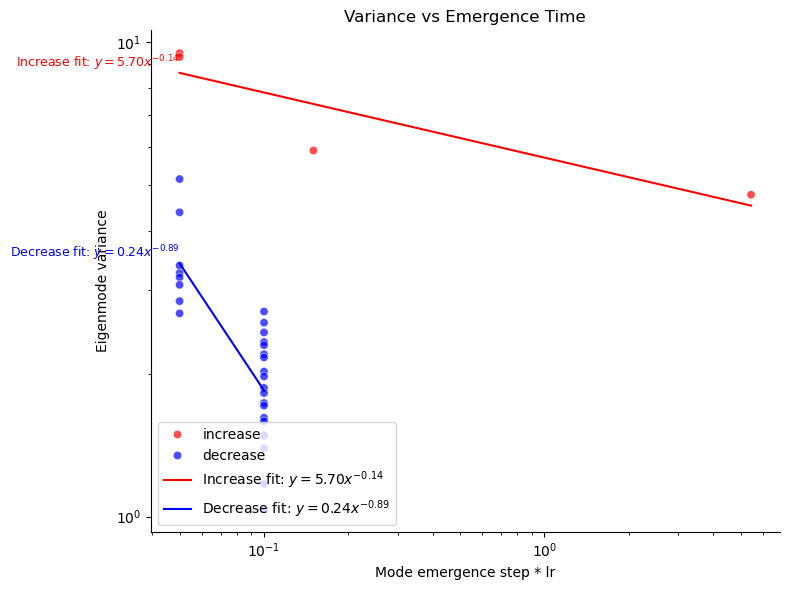

In [ ]:
# 1. Plot variance trajectories
plot_variance_trajectories(
    step_slice, 
    diag_cov_x_sample_true_eigenbasis_traj.cpu(), 
    img_eigval.cpu(), 
    slice2plot=slice(0, 32, 3),  
    patch_size=1, 
    patch_stride=1, 
    savedir=expdir, 
    dataset_name="FFHQ_DC-AE_256px"
)
# 2. Compute crossing points
lr = 1e-4
lr_step_slice = np.array(step_slice) * lr
df = compute_crossing_points(
    img_eigval, 
    diag_cov_x_sample_true_eigenbasis_traj.cpu(), 
    lr_step_slice, 
    smooth_sigma=1, 
    threshold_type="harmonic_mean"
)
df.to_csv(f"{expdir}/eigenmode_emergence_vs_variance_patch{patch_size}x{patch_size}_stride{patch_stride}.csv", index=False)
# 3. Plot and analyze emergence scaling
figh = analyze_and_plot_variance(
    df, 
    x_col='emergence_step', 
    y_col='Variance', 
    hue_col='Direction',
    palette={"increase": "red", "decrease": "blue"},
    log_x=True, 
    log_y=True,
    title='Variance vs Emergence Time',
    xlabel='Mode emergence step * lr',
    ylabel='Eigenmode variance'
)

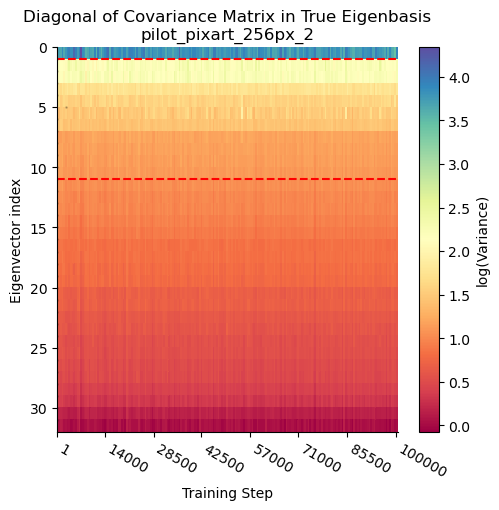

In [29]:
var_ratio = diag_cov_x_sample_true_eigenbasis_traj[0,:] / img_eigval.cpu()
eig_idx_tooclose = (var_ratio > 0.5) & (var_ratio < 2)
eig_idx_tooclose_vec = eig_idx_tooclose.nonzero()[:,0]

plt.figure(figsize=(5.5, 5))
plt.pcolor(diag_cov_x_sample_true_eigenbasis_traj.log().cpu().numpy().T, cmap="Spectral", rasterized=True)
plt.colorbar(label="log(Variance)")
plt.scatter(df["emergence_step"].to_numpy(), df.index.to_numpy(), marker=".", c="k", s=3, alpha=0.2, rasterized=True)
plt.axhline(eig_idx_tooclose_vec[0], color="r", linestyle="--")
plt.axhline(eig_idx_tooclose_vec[-1], color="r", linestyle="--")
plt.title(f"Diagonal of Covariance Matrix in True Eigenbasis\n{expname}")
plt.xlabel("Training Step")
plt.ylabel("Eigenvector index")
plt.gca().invert_yaxis()  # Flip the y-axis
# annotate x-axis with step_slice
# Only show a subset of ticks to avoid overcrowding
tick_indices = np.linspace(0, len(step_slice)-1, 8, dtype=int)
plt.xticks(tick_indices, [step_slice[i] for i in tick_indices], rotation=-30, ha="left")
# saveallforms([figdir, synopsis_dir], f"eigenframe_variance_heatmap_{expname}_rasterized", dpi=300)
plt.show()

### Dense sampling

In [71]:
exproot = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionReprCondModel/"
expname = "pilot_pixart_FFHQ_256px_densesample"
expdir = join(exproot, expname)
sampledir = join(expdir, "samples")

In [77]:
# Load all samples from directory
sample_store = sweep_and_create_sample_store_custom_pattern(sampledir)

regex_pattern: latents_epoch_(\d+)\.pt


  0%|          | 0/506 [00:00<?, ?it/s]

/n/home12/binxuwang/Github/DiffusionLearningCurve/core/img_patch_stats_analysis_lib.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample_store[epoch] = torch.load(sam

In [78]:
IN1k_val_dir = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/Datasets/imagenet-valid/"
latent_dir = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/Datasets/dcae_latents"
resolution = 256
model_ver_short = "dc-ae-f32c32-mix-1.0"
latent_tsr = torch.load(join(latent_dir, f"ffhq256_{resolution}px_{model_ver_short}_latent_tsr.pt"), weights_only=False)
# latent_tsr = torch.load(join(IN1k_val_dir, f"IN1k_valid_{model_ver_short}_latent_tsr.pt"), weights_only=False)

In [79]:
result = process_img_mean_cov_statistics(
            latent_tsr.contiguous(), sample_store, expdir, device="cuda", imgshape=(32, 8, 8), save_pkl=True)
img_mean, img_cov, img_eigval, img_eigvec, \
        mean_x_sample_traj, cov_x_sample_traj, diag_cov_x_sample_true_eigenbasis_traj = result

img_cov.shape: torch.Size([2048, 2048]) computed on 70000 images


  0%|          | 0/506 [00:00<?, ?it/s]

Saved to /n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionReprCondModel/pilot_pixart_FFHQ_256px_densesample/sample_img_cov_true_eigenbasis_diag_traj.pkl


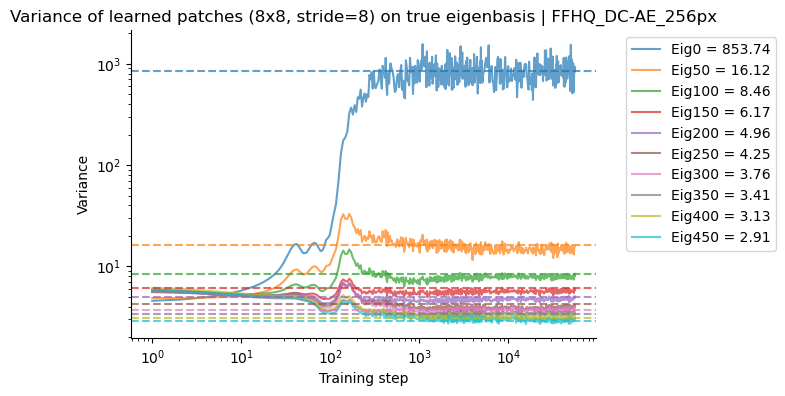

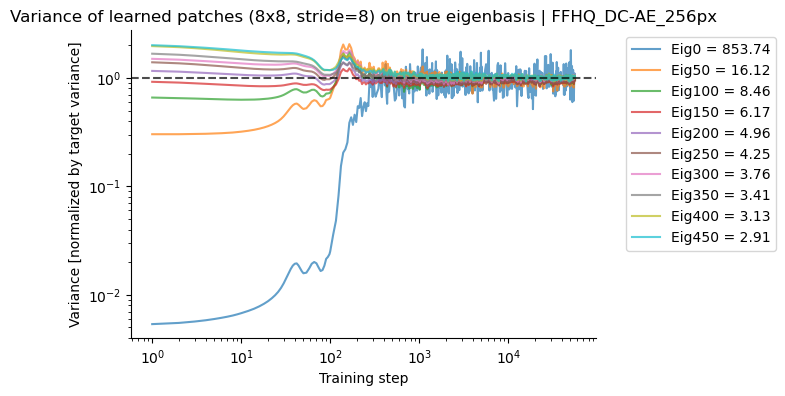

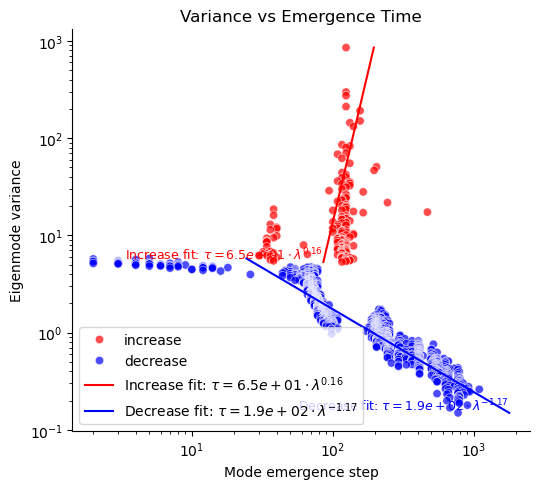

In [80]:
step_slice = sorted(list(sample_store.keys()))
# 1. Plot variance trajectories
plot_variance_trajectories(
    step_slice, 
    diag_cov_x_sample_true_eigenbasis_traj.cpu(), 
    img_eigval.cpu(), 
    slice2plot=slice(0, 500, 50),  
    patch_size=8, 
    patch_stride=8, 
    savedir=expdir, 
    dataset_name="FFHQ_DC-AE_256px"
)
# 2. Compute crossing points
# lr = 1e-4
# lr_step_slice = np.array(step_slice) * lr
df = compute_crossing_points(
    img_eigval.cpu(), 
    diag_cov_x_sample_true_eigenbasis_traj.cpu(), 
    step_slice, 
    smooth_sigma=1, 
    threshold_type="geometric_mean"
)
df.to_csv(f"{expdir}/eigenmode_emergence_vs_variance.csv", index=False)

# 3. Plot and analyze emergence scaling
figh = analyze_and_plot_variance(
    df, 
    x_col='emergence_step', 
    y_col='Variance', 
    hue_col='Direction',
    palette={"increase": "red", "decrease": "blue"},
    log_x=True, 
    log_y=True,
    figsize=(5.5, 5),
    reverse_equation=True,
    fit_label_format='{direction} fit: $\\tau = {a:.1e} \\cdot \\lambda^{{{b:.2f}}}$',
    title='Variance vs Emergence Time',
    xlabel='Mode emergence step',
    ylabel='Eigenmode variance'
)